In [93]:
import numpy as np
import matplotlib.pyplot as plt

def rk4(model, state, t, dt):
    """Runge-Kutta time-stepping scheme.
    
    Inputs:
    model -- function/model on which we want to use RK4
    state [np.ndarray] -- state vector
    t [numeric] -- total time
    dt [numeric] -- time step

    """

    k1 = model(t, state)
    k2 = model(t + dt/2, state + dt * k1/2)
    k3 = model(t + dt/2, state + dt * k2/2)
    k4 = model(t + dt, state + dt * k3)

    return state + (dt/6) * (k1 + 2 * k2 + 2 * k3 + k4)

    

def lorenz_63(t, state, r=28, s=10, b=8/3):
    '''Returns time derivatives of x, y, z for
      Lorenz system (1963) based on inputted parameter values.

      Arguments:
      t [numeric] -- time
      state [np.ndarray] -- State vector v = [x, y, z]
      r [numeric] -- Rayleigh number.
      s [numeric] -- Prandtl number. Conventional value = 10
      b [numeric] -- Aspect ratio parameter. Conventional value = 8/3
      
      Returns:
      np.array([dxdt, dydt, dzdt]) -- Calculated time derivatives
      '''
    x, y, z = state
    dxdt = s * (y - x)
    dydt = x * (r - z) - y
    dzdt = x * y - b * z

    return np.array([dxdt, dydt, dzdt])



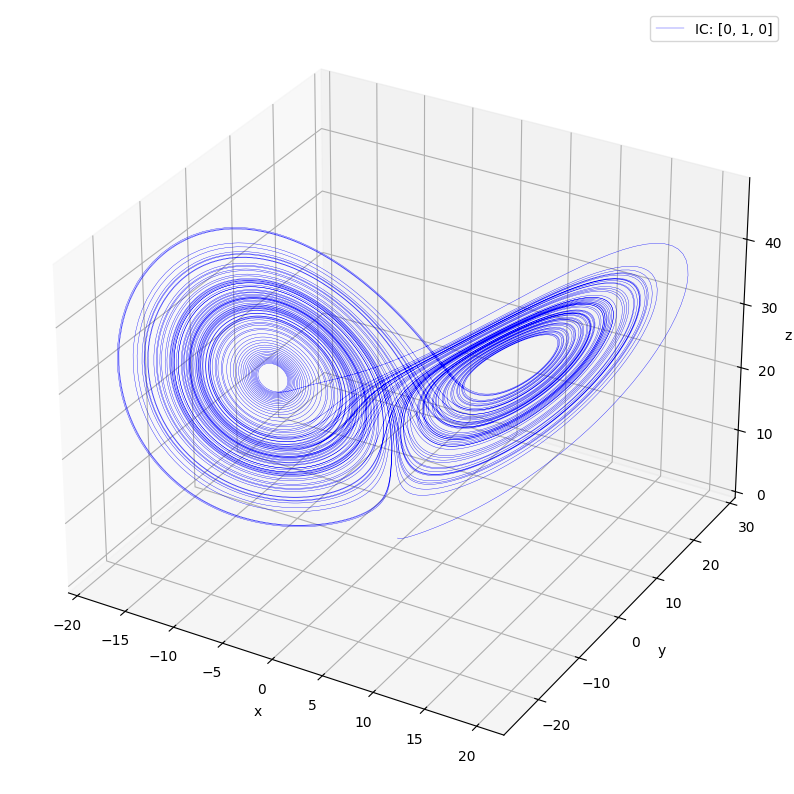

In [ ]:
#Plot with standard parameter values and IC [0, 1, 0]
#Prompt 3
v = np.array([0,1,0])
T = 100
dt = 0.005
t = np.arange(0, T, dt) #time steps

chaos = np.zeros((3, int(T/dt))) #initialize results
chaos[:, 0] = v #set first entry to be IC
                 
for i in range(len(t)-1):
  v = rk4(lorenz_63, v, t[i], dt)
  chaos[:, i+1] = v

fig = plt.figure(figsize=(10, 12)) 
ax = plt.axes(projection='3d')
ax.plot3D(chaos[0], chaos[1], chaos[2], label = 'IC: [0, 1, 0]', linewidth=0.25, c='b')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.zaxis.labelpad=-0.7
ax.legend()
plt.show()

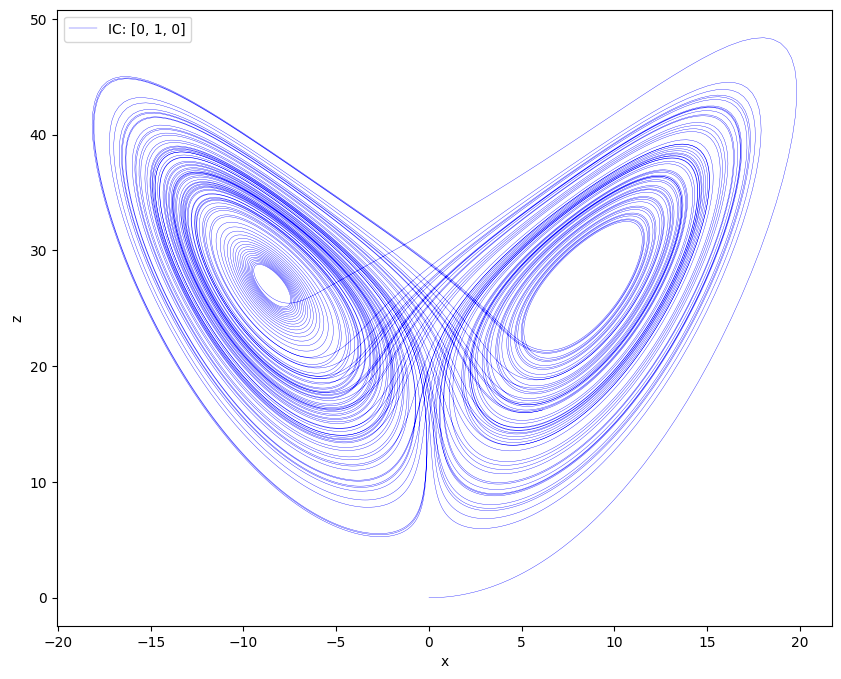

In [ ]:
#Plot with standard parameter values and IC [0, 1, 0]
#2D
#Prompt 3
v = np.array([0,1,0])
T = 100
dt = 0.005
t = np.arange(0, T, dt) #time steps

chaos = np.zeros((3, int(T/dt))) #initialize results
chaos[:, 0] = v #set first entry to be IC
                 
for i in range(len(t)-1):
  v = rk4(lorenz_63, v, t[i], dt)
  chaos[:, i+1] = v

fig = plt.figure(figsize=(10, 8)) 
plt.plot(chaos[0], chaos[2], label = 'IC: [0, 1, 0]', linewidth=0.25, c='b')
plt.xlabel('x')
plt.ylabel('z')
plt.legend()
plt.show()

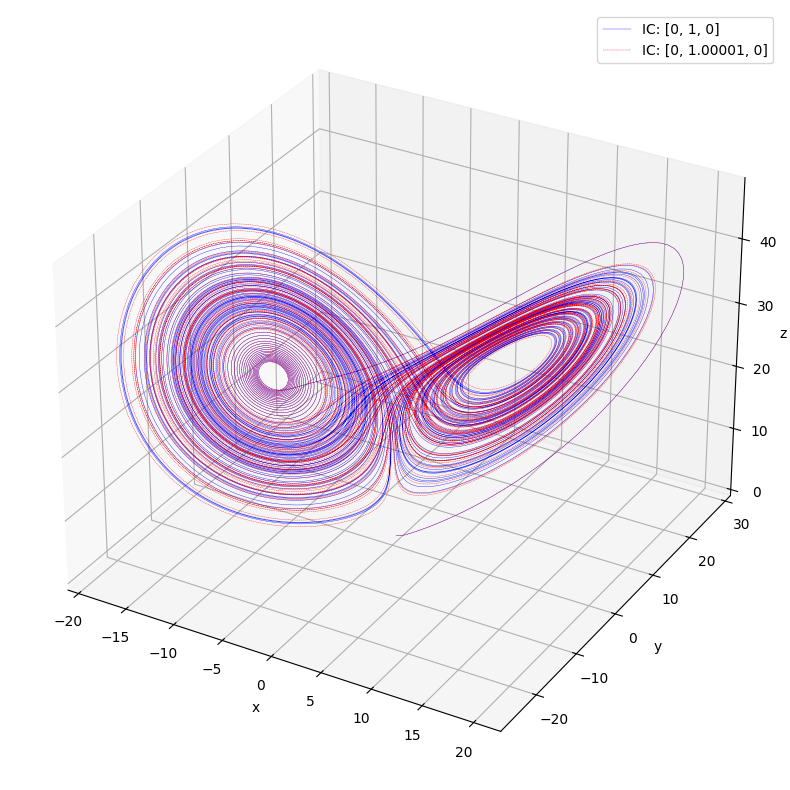

In [ ]:
#Plot and compare 2 similar ICs
#Plot
#Prompt 3
v1 = np.array([0,1,0])
v2 = np.array([0,1.0001,0])
T = 100
dt = 0.005
t = np.arange(0, T, dt) #time steps

chaos1 = np.zeros((3, int(T/dt))) #initialize results
chaos1[:, 0] = v1 #set first entry to be IC

chaos2 = np.zeros((3, int(T/dt))) #initialize results
chaos2[:, 0] = v2 #set first entry to be IC
                 
for i in range(len(t)-1):
  v1 = rk4(lorenz_63, v1, t[i], dt)
  chaos1[:, i+1] = v1

for i in range(len(t)-1):
  v2 = rk4(lorenz_63, v2, t[i], dt)
  chaos2[:, i+1] = v2

fig = plt.figure(figsize=(12, 10)) 
ax = plt.axes(projection='3d')
ax.plot3D(chaos1[0], chaos1[1], chaos1[2], label = 'IC: [0, 1, 0]',linewidth=0.25, c='b')
ax.plot3D(chaos2[0], chaos2[1], chaos2[2], label = 'IC: [0, 1.00001, 0]', linewidth=0.25, c='r', linestyle='--')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.zaxis.labelpad=-0.7
ax.legend()
plt.show()

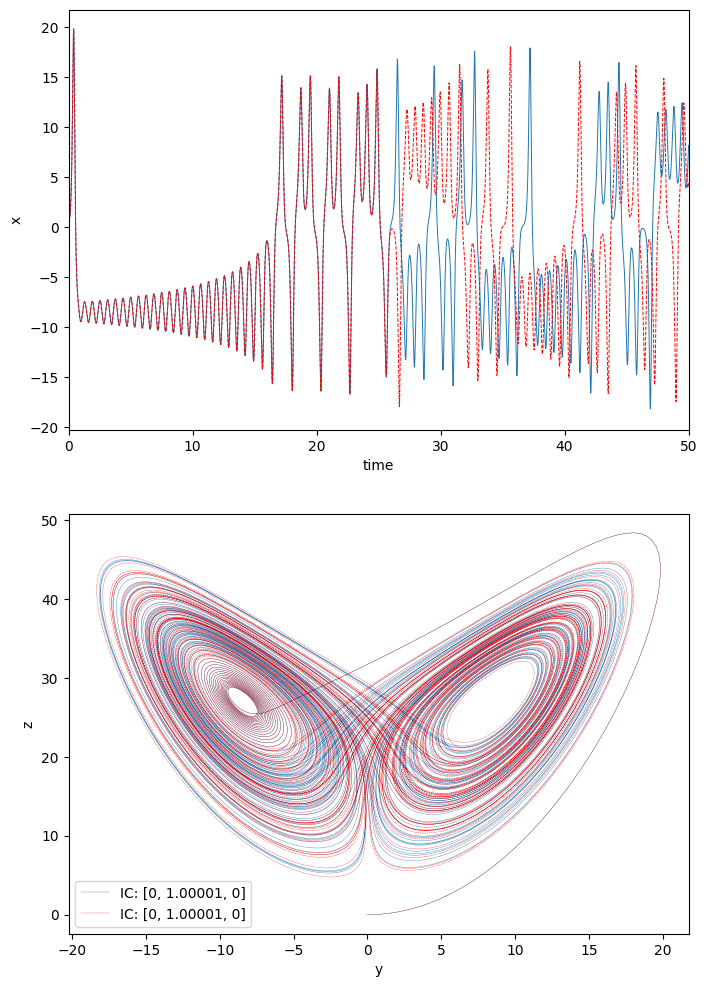

In [ ]:

#Plot and compare 2 similar ICs
#Plot
#Prompt 3
v1 = np.array([0,1,0])
v2 = np.array([0,1.0001,0])
T = 100
dt = 0.005
t = np.arange(0, T, dt) #time steps

chaos1 = np.zeros((3, int(T/dt))) #initialize results
chaos1[:, 0] = v1 #set first entry to be IC

chaos2 = np.zeros((3, int(T/dt))) #initialize results
chaos2[:, 0] = v2 #set first entry to be IC
                 
for i in range(len(t)-1):
  v1 = rk4(lorenz_63, v1, t[i], dt)
  chaos1[:, i+1] = v1

for i in range(len(t)-1):
  v2 = rk4(lorenz_63, v2, t[i], dt)
  chaos2[:, i+1] = v2

plt.figure(figsize=(8, 12)) 
plt.subplot(211)
plt.plot(t, chaos1[0], label = 'IC: [0, 1, 0]', linewidth = 0.7)
plt.plot(t, chaos2[0], label = 'IC: [0, 1.00001, 0]', linewidth=0.7, linestyle = '--', c='r')
plt.xlim(0,50)
plt.xlabel('time')
plt.ylabel('x')

plt.subplot(212)
plt.plot(chaos1[0], chaos1[2], label = 'IC: [0, 1.00001, 0]', linewidth=0.25)
plt.plot(chaos2[0], chaos2[2], label = 'IC: [0, 1.00001, 0]', linewidth=0.25, linestyle = '--', c='r')
plt.xlabel('y')
plt.ylabel('z')
plt.legend()
plt.show()

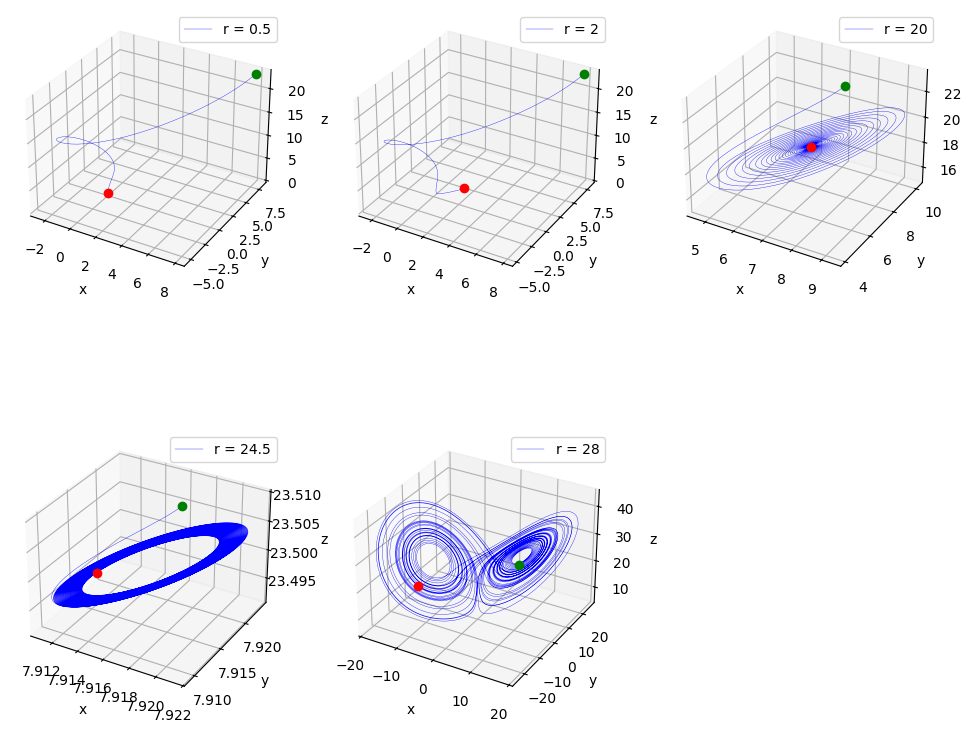

In [765]:
#Plot with varying Rayleigh number, r
#3D
#Prompt 3a
def lorenz_r(t,state):
    return lorenz_63(t, state, r=r)
    
T = 50
dt = 0.005
t = np.arange(0, T, dt) #time steps
rvals = [0.5, 2, 20, 24.5, 28]


fig, ax = plt.subplots(2,3,figsize=(12, 10),subplot_kw={'projection': '3d'}) 
ax = ax.flatten()

for j in range(0,5):
    r = rvals[j]
    v_r = np.array([np.sqrt(8/3*(24.51-1)),np.sqrt(8/3*(24.51-1)),24.51-1]) #reset to IC every loop
    #v_r = np.array([0,1,0]) #reset to IC every loop
    chaos_r = np.zeros((3, int(T/dt))) #initialize results
    chaos_r[:, 0] = v_r #set first entry to be IC         
    for i in range(len(t)-1):
        v_r = rk4(lorenz_r, v_r, t[i], dt)
        chaos_r[:, i+1] = v_r
    first = chaos_r[:,0]
    last = chaos_r[:,-1]

    ax[j].plot3D(chaos_r[0], chaos_r[1], chaos_r[2], label = f"r = {r}", linewidth=0.25, c='b')
    ax[j].plot3D(first[0], first[1], first[2], marker='o',c='g')
    ax[j].plot3D(last[0], last[1], last[2], marker='o',c='r')
    ax[j].set_xlabel('x')
    ax[j].set_ylabel('y')
    ax[j].set_zlabel('z')
    ax[j].legend()
fig.delaxes(ax[5])
plt.show()

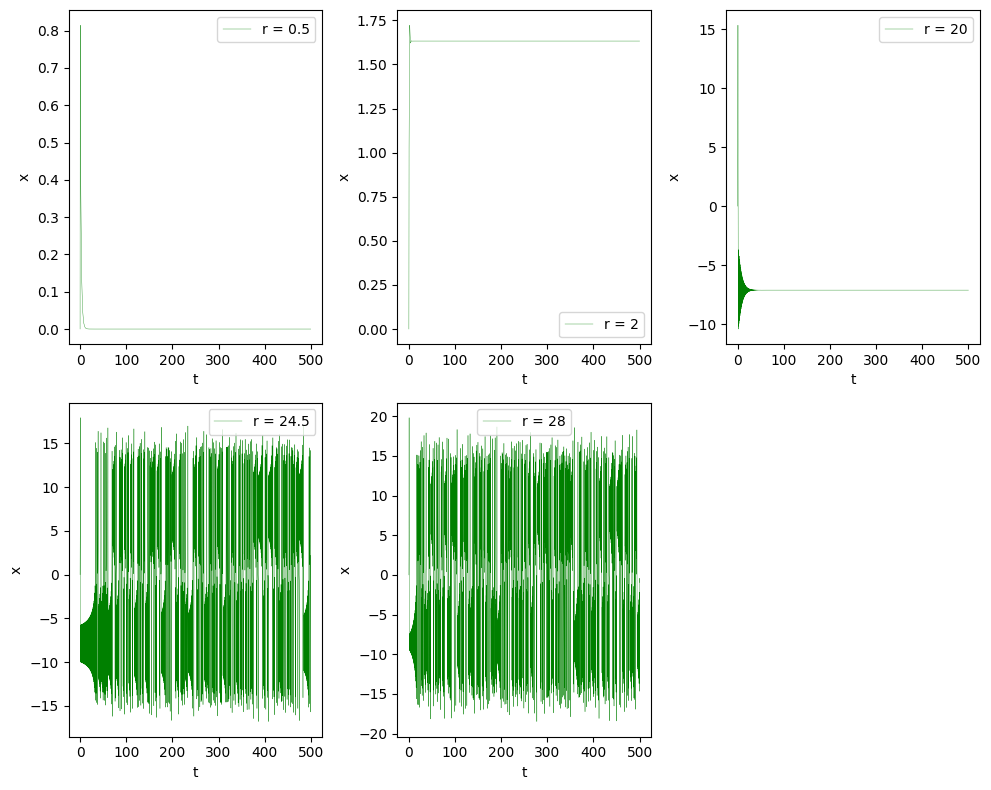

In [773]:
#Plot with varying Rayleigh number, r
#on x, y

def lorenz_r(t,state):
    return lorenz_63(t, state, r=r)
    
T = 500
dt = 0.005
t = np.arange(0, T, dt) #time steps
rvals = [0.5, 2, 20, 24.5, 28]


fig, ax = plt.subplots(2,3,figsize=(10, 8)) 
ax = ax.flatten()

for j in range(0,5):
    r = rvals[j]
    v_r = np.array([0,1,0]) #reset to IC every loop
    #v_r = np.array([np.sqrt(8/3*(24.5-1))+0.0001,np.sqrt(8/3*(24.5-1))+0.0001,24.5-1+0.0001]) #reset to IC every loop
    chaos_r = np.zeros((3, int(T/dt))) #initialize results
    chaos_r[:, 0] = v_r #set first entry to be IC         
    for i in range(len(t)-1):
        v_r = rk4(lorenz_r, v_r, t[i], dt)
        chaos_r[:, i+1] = v_r

    ax[j].plot(t, chaos_r[0], label = f"r = {r}", linewidth=0.25, c='g')
    ax[j].set_xlabel('t')
    ax[j].set_ylabel('x')
    ax[j].legend()
fig.delaxes(ax[5])
plt.tight_layout()
plt.show()

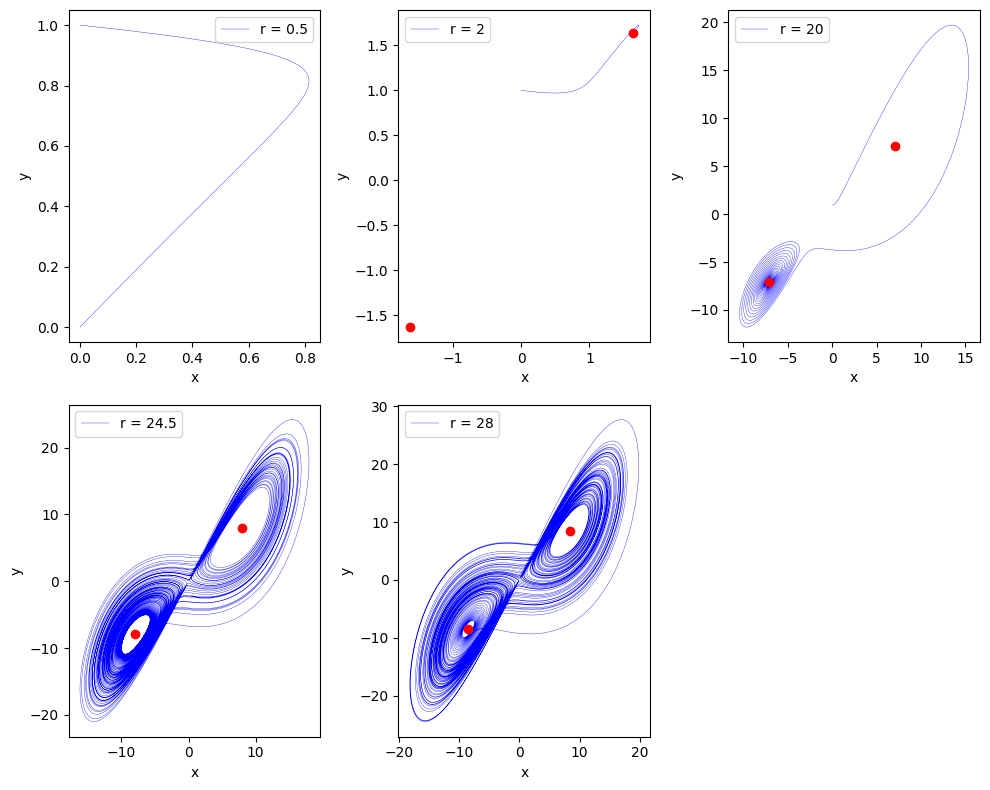

In [485]:
#Plot with varying Rayleigh number, r
#2D
def lorenz_r(t,state):
    return lorenz_63(t, state, r=r)
    
T = 100
dt = 0.005
t = np.arange(0, T, dt) #time steps
rvals = [0.5, 2, 20, 24.5, 28]


fig, ax = plt.subplots(2,3,figsize=(10, 8)) 
ax = ax.flatten()

for j in range(0,5):
    r = rvals[j]
    v_r = np.array([0,1,0]) #reset to IC every loop
    chaos_r = np.zeros((3, int(T/dt))) #initialize results
    chaos_r[:, 0] = v_r #set first entry to be IC         
    for i in range(len(t)-1):
        v_r = rk4(lorenz_r, v_r, t[i], dt)
        chaos_r[:, i+1] = v_r

    ax[j].plot(chaos_r[0], chaos_r[1], label = f"r = {r}", linewidth=0.25, c='b')
    ax[j].set_xlabel('x')
    ax[j].set_ylabel('y')
    ax[j].legend()
    if r > 1:
        x_fp = np.sqrt((r-1)*(8/3))
        ax[j].plot(x_fp,x_fp, marker='o',c='r')
        ax[j].plot(-x_fp,-x_fp, marker='o',c='r')
    else:
        continue

fig.delaxes(ax[5])
plt.tight_layout()
plt.show()

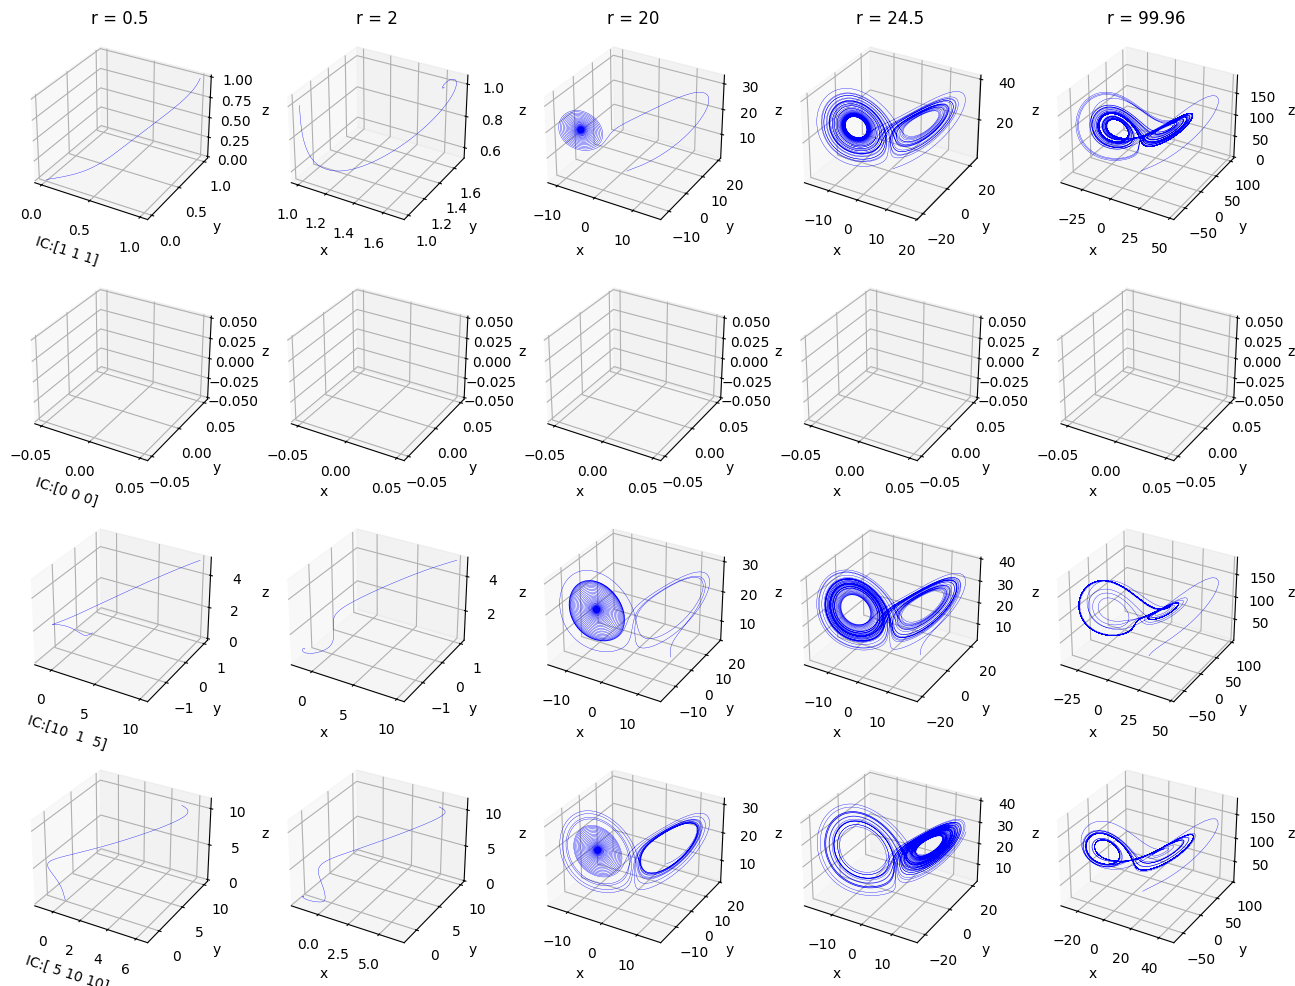

In [ ]:
#Plot with varying IC and varying r
#3D
def lorenz_r(t,state):
    return lorenz_63(t, state, r=r)
    
T = 50
dt = 0.005
t = np.arange(0, T, dt) #time steps
rvals = [0.5, 2, 20, 24.5, 28]

v_a = np.array([1,1,1])
v_b = np.array([0,0,0])
v_c = np.array([10,1,5])
v_d = np.array([5,10,10])

IC = np.array([v_a,v_b,v_c,v_d])

fig, ax = plt.subplots(4,5,figsize=(16, 12),subplot_kw={'projection': '3d'}) 

cols = ['r = {}'.format(r) for r in rvals]
rows = ['IC: [{}]'.format(ic) for ic in IC]

for k in range(0,4):
    for j in range(0,5):
        r = rvals[j]
        v_r = IC[k]
        chaos_r = np.zeros((3, int(T/dt))) #initialize results
        chaos_r[:, 0] = v_r #set first entry to be IC         
        for i in range(len(t)-1):
            v_r = rk4(lorenz_r, v_r, t[i], dt)
            chaos_r[:, i+1] = v_r

        ax[k,j].plot3D(chaos_r[0], chaos_r[1], chaos_r[2], linewidth=0.25, c='b')
        ax[k,j].set_xlabel('x')
        ax[k,j].set_ylabel('y')
        ax[k,j].set_zlabel('z')
        ax[k,0].set_xlabel(f'IC:{IC[k]}',rotation=180)

for ax, col in zip(ax[0], cols):
    ax.set_title(col)
fig.subplots_adjust(wspace=0.2, hspace=0.2)
    
plt.show()

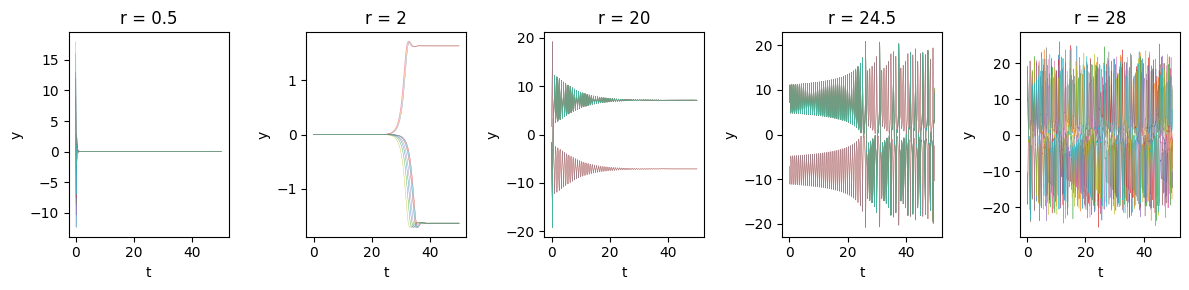

In [ ]:
#Plot with varying IC and varying r
#2D
import random


def lorenz_r(t,state):
    return lorenz_63(t, state, r=r)
    
T = 50
dt = 0.005
t = np.arange(0, T, dt) #time steps
rvals = [0.5, 2, 20, 24.5, 28]

fig, ax = plt.subplots(1,5,figsize=(12, 3)) 

for k in range(0,10):
    random_x = random.randint(0, 20)
    random_y = random.randint(0, 20)
    random_z = random.randint(1, 40)
    v_r = [random_x,random_y, random_z]
    for j in range(0,5):
        r = rvals[j]
        chaos_r = np.zeros((3, int(T/dt))) #initialize results
        chaos_r[:, 0] = v_r #set first entry to be IC         
        for i in range(len(t)-1):
            v_r = rk4(lorenz_r, v_r, t[i], dt)
            chaos_r[:, i+1] = v_r

        ax[j].plot(t, chaos_r[1], linewidth=0.25)
        ax[j].set_title(f'r = {r}')
        ax[j].set_xlabel('t')
        ax[j].set_ylabel('y')

plt.tight_layout()
plt.show()

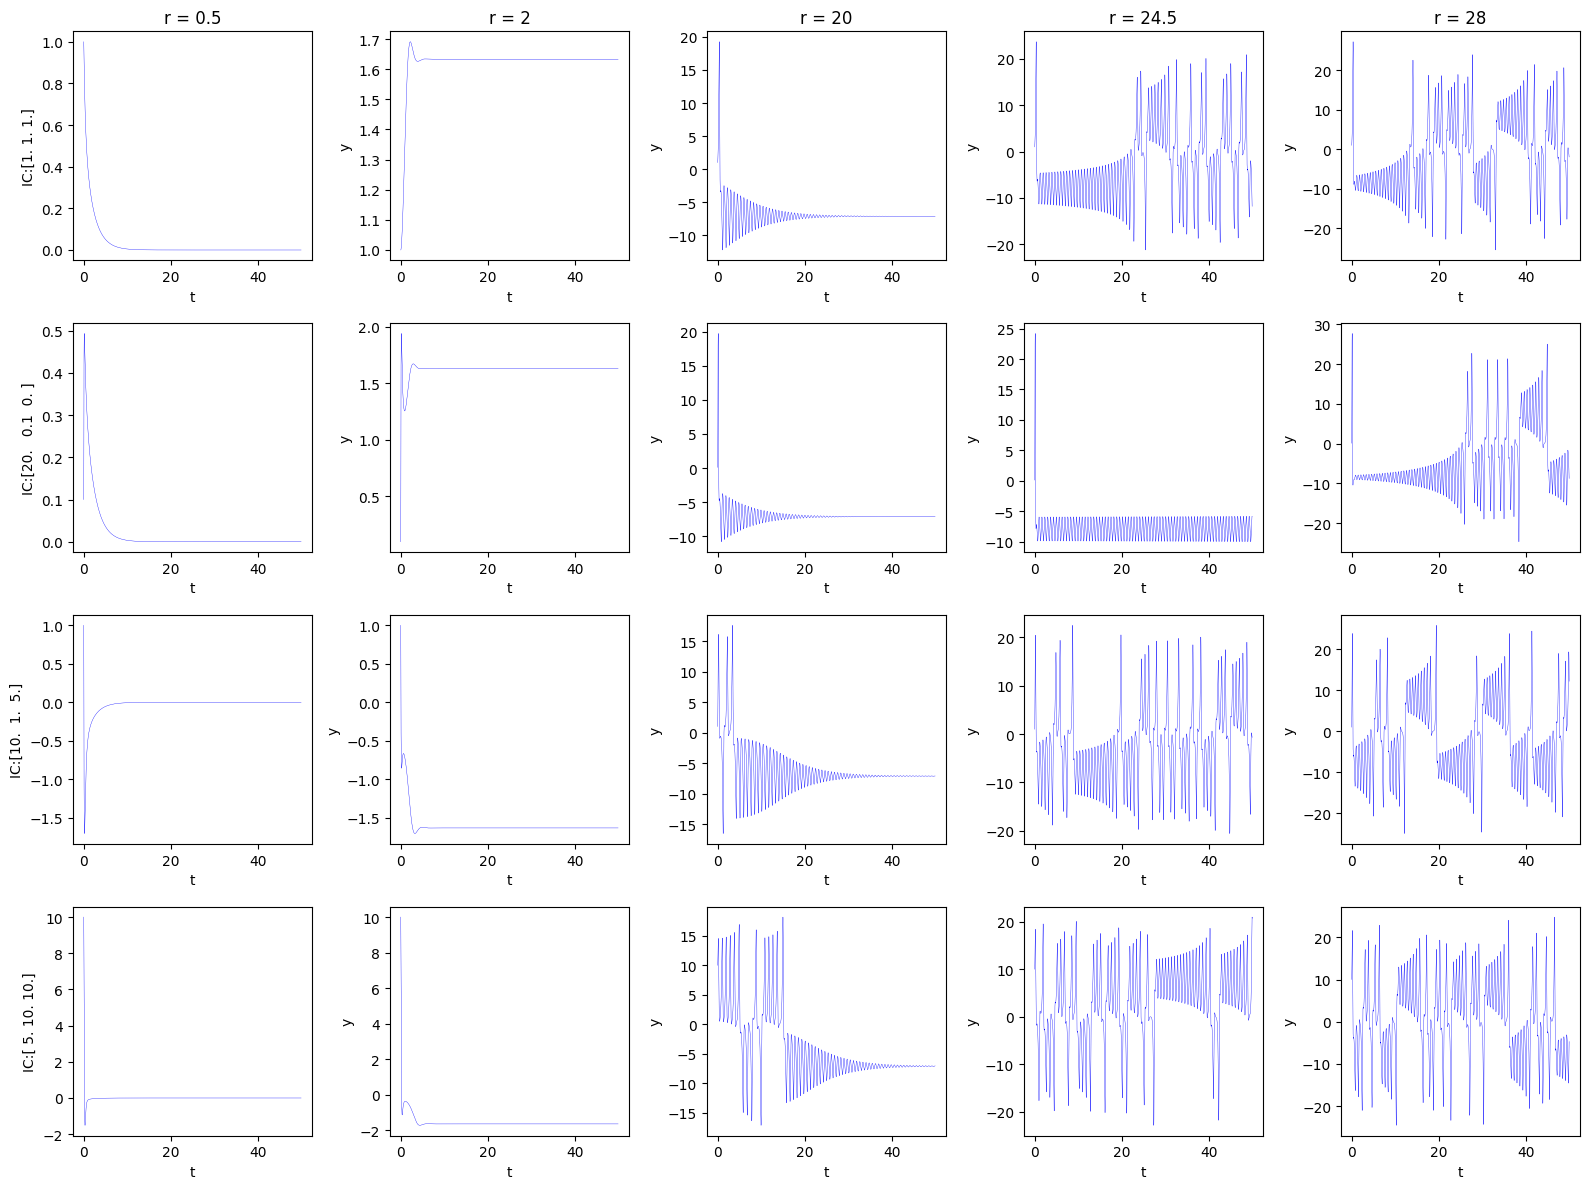

In [477]:
#Plot with varying IC and varying r
#z against t
def lorenz_r(t,state):
    return lorenz_63(t, state, r=r)
    
T = 50
dt = 0.005
t = np.arange(0, T, dt) #time steps
rvals = [0.5, 2, 20, 24.5, 28]

v_a = np.array([1,1,1])
v_b = np.array([20,0.1,0])
v_c = np.array([10,1,5])
v_d = np.array([5,10,10])

IC = np.array([v_a,v_b,v_c,v_d])

fig, ax = plt.subplots(4,5,figsize=(16, 12)) 

cols = ['r = {}'.format(r) for r in rvals]
rows = ['IC: [{}]'.format(ic) for ic in IC]

for k in range(0,4):
    for j in range(0,5):
        r = rvals[j]
        v_r = IC[k]
        chaos_r = np.zeros((3, int(T/dt))) #initialize results
        chaos_r[:, 0] = v_r #set first entry to be IC         
        for i in range(len(t)-1):
            v_r = rk4(lorenz_r, v_r, t[i], dt)
            chaos_r[:, i+1] = v_r

        ax[k,j].plot(t, chaos_r[1], linewidth=0.25, c='b')
        ax[k,j].set_xlabel('t')
        ax[k,j].set_ylabel('y')
        ax[k,0].set_ylabel(f'IC:{IC[k]}')

for ax, col in zip(ax[0], cols):
    ax.set_title(col)

fig.subplots_adjust(wspace=0.2, hspace=0.2)
plt.tight_layout()
plt.show()

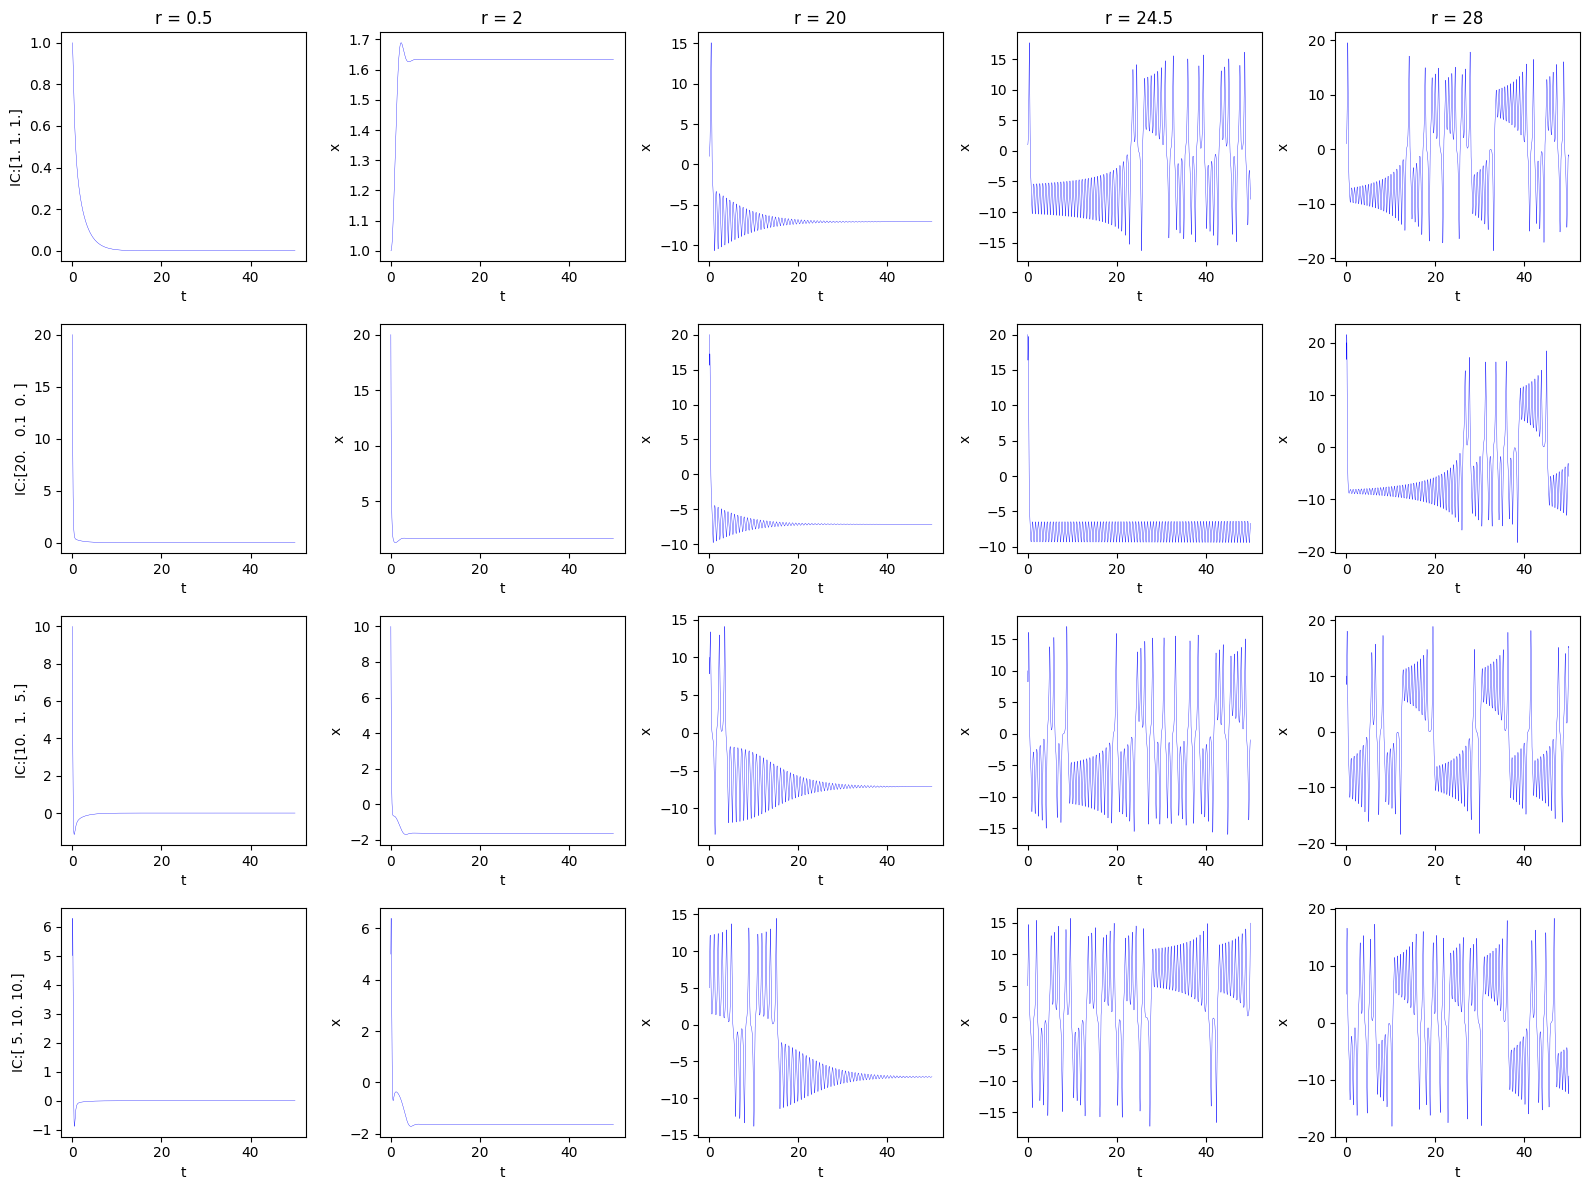

In [259]:
#Plot with varying IC and varying r
#x against t
def lorenz_r(t,state):
    return lorenz_63(t, state, r=r)
    
T = 50
dt = 0.005
t = np.arange(0, T, dt) #time steps
rvals = [0.5, 2, 20, 24.5, 28]

v_a = np.array([1,1,1])
v_b = np.array([20,0.1,0])
v_c = np.array([10,1,5])
v_d = np.array([5,10,10])

IC = np.array([v_a,v_b,v_c,v_d])

fig, ax = plt.subplots(4,5,figsize=(16, 12)) 

cols = ['r = {}'.format(r) for r in rvals]
rows = ['IC: [{}]'.format(ic) for ic in IC]

for k in range(0,4):
    for j in range(0,5):
        r = rvals[j]
        v_r = IC[k]
        chaos_r = np.zeros((3, int(T/dt))) #initialize results
        chaos_r[:, 0] = v_r #set first entry to be IC         
        for i in range(len(t)-1):
            v_r = rk4(lorenz_r, v_r, t[i], dt)
            chaos_r[:, i+1] = v_r

        ax[k,j].plot(t, chaos_r[0], linewidth=0.25, c='b')
        ax[k,j].set_xlabel('t')
        ax[k,j].set_ylabel('x')
        ax[k,0].set_ylabel(f'IC:{IC[k]}')

for ax, col in zip(ax[0], cols):
    ax.set_title(col)

fig.subplots_adjust(wspace=0.2, hspace=0.2)
plt.tight_layout()
plt.show()

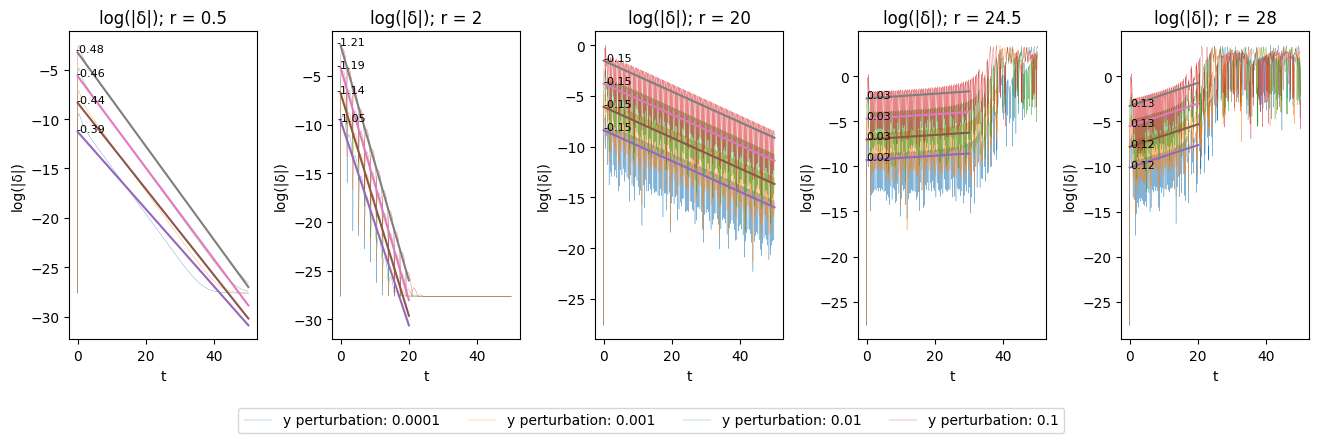

In [754]:
#Find Liapunov exponent
#2D
def lorenz_r(t,state):
    return lorenz_63(t, state, r=r)
    
T = 50
dt = 0.005
t = np.arange(0, T, dt) #time steps
rvals = [0.5, 2, 20, 24.5, 28] 

perturbations = [0.0001, 0.001, 0.01, 0.1]

fig, ax = plt.subplots(1,len(rvals),figsize=(16, 4)) 

IC = np.array([0,1,0])

v_pert =  np.array([0,1.0001,0])
v_pert2 =  np.array([0,1.001,0])
v_pert3 =  np.array([0,1.01,0])
v_pert4 =  np.array([0,1.1,0])


for j in range(0,5):
    r = rvals[j]

    v_a = np.array([0,1,0])
    v_pert =  np.array([0,1.0001,0])
    v_pert2 =  np.array([0,1.001,0])
    v_pert3 =  np.array([0,1.01,0])
    v_pert4 =  np.array([0,1.1,0])

    chaos_r = np.zeros((3, int(T/dt))) #initialize results
    chaos_pert =  np.zeros((3, int(T/dt))) 
    chaos_pert2 =  np.zeros((3, int(T/dt))) 
    chaos_pert3 =  np.zeros((3, int(T/dt))) 
    chaos_pert4 =  np.zeros((3, int(T/dt))) 
    
    chaos_r[:, 0] = v_a #set first entry to be IC
    chaos_pert[:,0] = v_pert
    chaos_pert2[:,0] = v_pert2
    chaos_pert3[:,0] = v_pert3
    chaos_pert4[:,0] = v_pert4


    for i in range(len(t)-1):
        v_a = rk4(lorenz_r, v_a, t[i], dt)
        chaos_r[:, i+1] = v_a

        v_pert = rk4(lorenz_r, v_pert, t[i], dt)
        chaos_pert[:, i+1] = v_pert

        v_pert2 = rk4(lorenz_r, v_pert2, t[i], dt)
        chaos_pert2[:, i+1] = v_pert2

        v_pert3 = rk4(lorenz_r, v_pert3, t[i], dt)
        chaos_pert3[:, i+1] = v_pert3

        v_pert4 = rk4(lorenz_r, v_pert4, t[i], dt)
        chaos_pert4[:, i+1] = v_pert4

        delta = np.abs(chaos_r[0]-chaos_pert[0])
        delta2 = np.abs(chaos_r[0]-chaos_pert2[0])
        delta3 = np.abs(chaos_r[0]-chaos_pert3[0])
        delta4 = np.abs(chaos_r[0]-chaos_pert4[0])
        
    if r in (0.5, 20):
        time_slice = slice(0, int(T/dt))
    elif r in (2, 28):
        time_slice = slice(0, int(20/dt))
    else:
        time_slice = slice(0, int(30/dt))
        
    logd = np.log(delta + 1e-12)
    logd2 = np.log(delta2 + 1e-12)
    logd3 = np.log(delta3 + 1e-12)
    logd4 = np.log(delta4 + 1e-12)

    m, b = np.polyfit(t[time_slice], logd[time_slice], 1)
    m2, b2 = np.polyfit(t[time_slice], logd2[time_slice], 1)
    m3, b3 = np.polyfit(t[time_slice], logd3[time_slice], 1)
    m4, b4 = np.polyfit(t[time_slice], logd4[time_slice], 1)

    ax[j].plot(t, logd, label='y perturbation: 0.0001', linewidth=0.2)
    ax[j].plot(t, logd2, label='y perturbation: 0.001', linewidth=0.2)
    ax[j].plot(t, logd3, label='y perturbation: 0.01', linewidth=0.2)
    ax[j].plot(t, logd4, label='y perturbation: 0.1', linewidth=0.2)

    ax[j].plot(t[time_slice], m*t[time_slice] + b)
    ax[j].plot(t[time_slice], m2*t[time_slice] + b2)
    ax[j].plot(t[time_slice], m3*t[time_slice] + b3)
    ax[j].plot(t[time_slice], m4*t[time_slice] + b4)
    ax[j].text(m,b,f'{m:.2f}', fontsize=8)
    ax[j].text(m2,b2,f'{m2:.2f}', fontsize=8)
    ax[j].text(m3,b3,f'{m3:.2f}', fontsize=8)
    ax[j].text(m4,b4,f'{m4:.2f}', fontsize=8)

    ax[j].set_title(f'log(|δ|); r = {r}')
    ax[j].set_xlabel('t')
    ax[j].set_ylabel('log(|δ|)')

plt.legend(loc='upper center', bbox_to_anchor=(-2.5, -0.2), ncol=4)
plt.subplots_adjust(wspace=0.4)
plt.show()

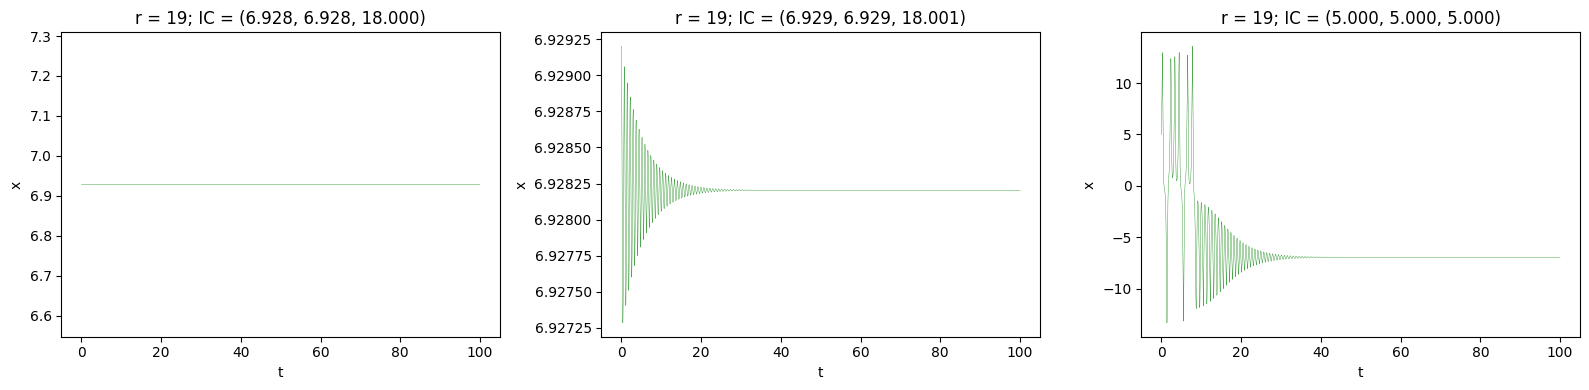

In [ ]:
#Plot with varying IC, Rayleigh number = 24.5
#on x, y

def lorenz_r(t,state):
    return lorenz_63(t, state, r=r)
    
T = 100
dt = 0.005
t = np.arange(0, T, dt) #time steps
ICs = [[np.sqrt(8/3*(19-1)),np.sqrt(8/3*(19-1)),18],[np.sqrt(8/3*(19-1))+0.001,np.sqrt(8/3*(19-1))+0.001,18.001],[5,5,5]]
r = 19

fig, ax = plt.subplots(1,3,figsize=(16, 4)) 
ax = ax.flatten()

for j in range(0,3):
    v_r = ICs[j]
    chaos_r = np.zeros((3, int(T/dt))) #initialize results
    chaos_r[:, 0] = v_r #set first entry to be IC         
    for i in range(len(t)-1):
        v_r = rk4(lorenz_r, v_r, t[i], dt)
        chaos_r[:, i+1] = v_r

    ax[j].plot(t, chaos_r[0], linewidth=0.25, c='g')
    ax[j].set_title(f"r = {r}; IC = ({ICs[j][0]:.3f}, {ICs[j][1]:.3f}, {ICs[j][2]:.3f})")
    ax[j].set_xlabel('t')
    ax[j].set_ylabel('x')
    

plt.tight_layout()
plt.show()